# 📊 Customer Retention & Cohort Analysis

### By Vanshika Gupta

The analysis includes data cleaning, exploratory data analysis,
customer retention analysis, cohort analysis, and business insights.

## 🎯 Business Objective

The objective of this project is to analyze customer purchasing behavior,
identify repeat purchasing patterns, measure customer retention, and
understand how customer cohorts behave over time.

The analysis aims to answer key business questions such as:

- How many customers are repeat customers?
- What percentage of customers return to make additional purchases?
- How does customer retention change over time?
- Which customers contribute the most revenue?
- Which countries generate the highest revenue?
- What insights can help improve customer retention and repeat purchases?

## 📂 Dataset Overview

This project uses the UCI Online Retail Dataset, which contains
transaction-level data from a UK-based online retail business.

### Dataset Details

- **Source:** UCI Machine Learning Repository
- **Original Records:** 541,909 transactions
- **Time Period:** December 2010 – December 2011
- **Number of Columns:** 8

### Key Columns

- **InvoiceNo:** Transaction/invoice number
- **StockCode:** Product code
- **Description:** Product description
- **Quantity:** Number of units purchased
- **InvoiceDate:** Transaction date and time
- **UnitPrice:** Price per unit
- **CustomerID:** Unique customer identifier
- **Country:** Customer's country

A Revenue column is created during data preparation using:

**Revenue = Quantity × UnitPrice**

#### Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

#### Load the Dataset

In [7]:
df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Exploratory Data Analysis

In [9]:
df.shape

(541909, 8)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [11]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [12]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
df.duplicated().sum()

5268

In [14]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### Data Cleaning

In [16]:
df_clean = df.copy()

In [17]:
df_clean = df_clean.dropna(subset=['CustomerID'])

In [18]:
df_clean = df_clean.drop_duplicates()

In [19]:
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

In [20]:
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

In [21]:
# Revenue Column 
df_clean['Revenue'] = (df_clean['Quantity'] * df_clean['UnitPrice'])

In [22]:
print("Raw rows:", len(df))
print("Clean rows:", len(df_clean))
print("\nMissing_values:")
print(df_clean.isnull().sum())

print("\nDuplicates:", df_clean.duplicated().sum())

print("\nQuantity range:", 
    df_clean['Quantity'].min(),
    "to",
    df_clean['Quantity'].max()
    )
print("UnitPrice range:",
    df_clean['UnitPrice'].min(),
    "to",
    df_clean['UnitPrice'].max()
    )

df_clean.head()

Raw rows: 541909
Clean rows: 392692

Missing_values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

Duplicates: 0

Quantity range: 1 to 80995
UnitPrice range: 0.001 to 8142.75


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


### Cohort Analysis

In [24]:
# Create Purchase Month
df_clean['PurchaseMonth'] = (df_clean['InvoiceDate'].dt.to_period('M').dt.to_timestamp())

df_clean[['InvoiceDate', 'PurchaseMonth']].head()

,InvoiceDate,PurchaseMonth
0,2010-12-01 08:26:00,2010-12-01
1,2010-12-01 08:26:00,2010-12-01
2,2010-12-01 08:26:00,2010-12-01
3,2010-12-01 08:26:00,2010-12-01
4,2010-12-01 08:26:00,2010-12-01


In [25]:
# First Purchase Month for each customer
df_clean['CohortMonth'] = (df_clean.groupby('CustomerID')['PurchaseMonth'].transform('min'))

df_clean[['CustomerID', 'InvoiceDate', 'PurchaseMonth', 'CohortMonth']].head(10)

,CustomerID,InvoiceDate,PurchaseMonth,CohortMonth
0,17850,2010-12-01 08:26:00,2010-12-01,2010-12-01
1,17850,2010-12-01 08:26:00,2010-12-01,2010-12-01
2,17850,2010-12-01 08:26:00,2010-12-01,2010-12-01
3,17850,2010-12-01 08:26:00,2010-12-01,2010-12-01
4,17850,2010-12-01 08:26:00,2010-12-01,2010-12-01
5,17850,2010-12-01 08:26:00,2010-12-01,2010-12-01
6,17850,2010-12-01 08:26:00,2010-12-01,2010-12-01
7,17850,2010-12-01 08:28:00,2010-12-01,2010-12-01
8,17850,2010-12-01 08:28:00,2010-12-01,2010-12-01
9,13047,2010-12-01 08:34:00,2010-12-01,2010-12-01


In [26]:
# Create Cohort Index 
purchase_year = df_clean['PurchaseMonth'].dt.year
purchase_month = df_clean['PurchaseMonth'].dt.month

cohort_year = df_clean['CohortMonth'].dt.year
cohort_month = df_clean['CohortMonth'].dt.month

year_diff = purchase_year - cohort_year
month_diff = purchase_month - cohort_month

df_clean['CohortIndex'] = year_diff * 12 + month_diff + 1 

df_clean[['CustomerID', 'PurchaseMonth', 'CohortMonth', 'CohortIndex']].head(20)

,CustomerID,PurchaseMonth,CohortMonth,CohortIndex
0,17850,2010-12-01,2010-12-01,1
1,17850,2010-12-01,2010-12-01,1
2,17850,2010-12-01,2010-12-01,1
3,17850,2010-12-01,2010-12-01,1
4,17850,2010-12-01,2010-12-01,1
5,17850,2010-12-01,2010-12-01,1
6,17850,2010-12-01,2010-12-01,1
7,17850,2010-12-01,2010-12-01,1
8,17850,2010-12-01,2010-12-01,1
9,13047,2010-12-01,2010-12-01,1


In [27]:
df_clean['CohortIndex'].value_counts().sort_index()

CohortIndex
1     116857
2      27516
3      26727
4      26993
5      25165
6      26673
7      23462
8      23298
9      22751
10     22968
11     20098
12     23011
13      7173
Name: count, dtype: int64

In [28]:
# Count unique customers in each cohort and cohort index 
cohort_data = (df_clean.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index())

cohort_data.head(20)

,CohortMonth,CohortIndex,CustomerID
0,2010-12-01,1,885
1,2010-12-01,2,324
2,2010-12-01,3,286
3,2010-12-01,4,340
4,2010-12-01,5,321
5,2010-12-01,6,352
6,2010-12-01,7,321
7,2010-12-01,8,309
8,2010-12-01,9,313
9,2010-12-01,10,350


In [29]:
# Create Cohort Matrix 
cohort_matrix = cohort_data.pivot(index= 'CohortMonth', columns= 'CohortIndex', values= 'CustomerID')

cohort_matrix 

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02-01,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03-01,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04-01,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05-01,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06-01,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
## Retention Rate Matrix
# Get the initial number of customers in each cohort
cohort_size = cohort_matrix.iloc[:, 0]

cohort_size

CohortMonth
2010-12-01    885.0
2011-01-01    417.0
2011-02-01    380.0
2011-03-01    452.0
2011-04-01    300.0
2011-05-01    284.0
2011-06-01    242.0
2011-07-01    188.0
2011-08-01    169.0
2011-09-01    299.0
2011-10-01    358.0
2011-11-01    323.0
2011-12-01     41.0
Name: 1, dtype: float64

In [31]:
# Calculate customer retention rate
retention_matrix = cohort_matrix.divide(cohort_size, axis=0)

# Convert to percentage
retention_matrix = retention_matrix * 100

retention_matrix.round(2)

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,100.0,36.61,32.32,38.42,36.27,39.77,36.27,34.92,35.37,39.55,37.40,50.28,26.55
2011-01-01,100.0,22.06,26.62,23.02,32.13,28.78,24.70,24.22,29.98,32.61,36.45,11.75,NaN
2011-02-01,100.0,18.68,18.68,28.42,27.11,24.74,25.26,27.89,24.74,30.53,6.84,NaN,NaN
2011-03-01,100.0,15.04,25.22,19.91,22.35,16.81,26.77,23.01,27.88,8.63,NaN,NaN,NaN
2011-04-01,100.0,21.33,20.33,21.00,19.67,22.67,21.67,26.00,7.33,NaN,NaN,NaN,NaN
2011-05-01,100.0,19.01,17.25,17.25,20.77,23.24,26.41,9.51,NaN,NaN,NaN,NaN,NaN
2011-06-01,100.0,17.36,15.70,26.45,23.14,33.47,9.50,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,100.0,18.09,20.74,22.34,27.13,11.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,100.0,20.71,24.85,24.26,12.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


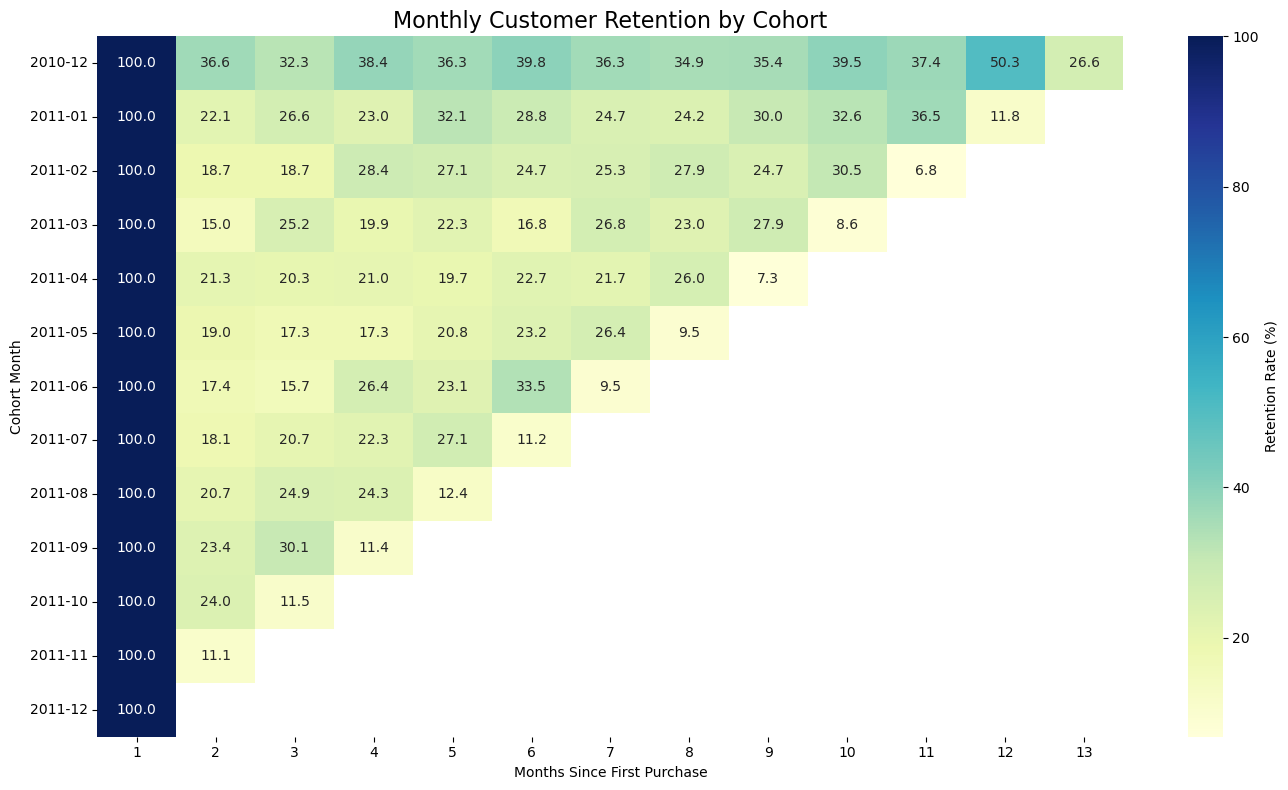

In [32]:
# Customer Retention Heatmap 

retention_plot = retention_matrix.copy()
retention_plot.index = retention_plot.index.strftime('%Y-%m')

plt.figure(figsize=(14,8))

sns.heatmap(
    retention_plot,
    annot= True,
    fmt= '.1f',
    cmap= 'YlGnBu',
    mask= retention_plot.isnull(),
    cbar_kws= {'label': 'Retention Rate (%)'}
)

plt.title('Monthly Customer Retention by Cohort', fontsize= 16)
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')

plt.tight_layout()
plt.show()

### Customer Retention Analysis 
##### One Time vs Repeat Customers

In [34]:
# Count unique orders placed by each customer
customer_orders = (df_clean.groupby('CustomerID')['InvoiceNo'].nunique().reset_index())

customer_orders.columns = ['CustomerID', 'TotalOrders']

# Classify Customers
customer_orders['CustomerType'] = np.where(customer_orders['TotalOrders'] > 1, 'Repeat Customer', 'One-Time-Customer')

customer_orders.head()

,CustomerID,TotalOrders,CustomerType
0,12346,1,One-Time-Customer
1,12347,7,Repeat Customer
2,12348,4,Repeat Customer
3,12349,1,One-Time-Customer
4,12350,1,One-Time-Customer


In [35]:
# Number of customers by type
customer_type_counts = customer_orders['CustomerType'].value_counts()
customer_type_counts

CustomerType
Repeat Customer      2845
One-Time-Customer    1493
Name: count, dtype: int64

In [36]:
# Percentage of customers by type
customer_type_percentage = (customer_orders['CustomerType'].value_counts(normalize= True).mul(100).round(2))
customer_type_percentage

CustomerType
Repeat Customer      65.58
One-Time-Customer    34.42
Name: proportion, dtype: float64

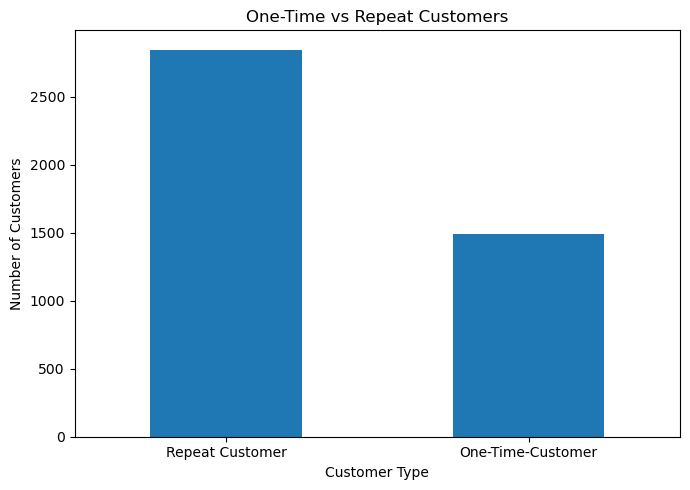

In [37]:
customer_type_counts.plot(kind='bar', figsize=(7,5))

plt.title('One-Time vs Repeat Customers')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation= 0)
plt.tight_layout()
plt.show()

##### Overall Repeat Customer Rate

In [39]:
total_customers = customer_orders['CustomerID'].nunique()

repeat_customers = (customer_orders['TotalOrders'] > 1).sum()

repeat_customer_rate = (repeat_customers / total_customers) * 100

print("Total Customers:", total_customers)
print("Repeat Customers:", repeat_customers)
print("Repeat Customer Rate:", round(repeat_customer_rate, 2), "%")

Total Customers: 4338
Repeat Customers: 2845
Repeat Customer Rate: 65.58 %


##### Revenue by Customer Type

In [41]:
# Add customer type to transaction-level data
customer_type_map = customer_orders.set_index('CustomerID')['CustomerType']

df_customer_analysis = df_clean.copy()

df_customer_analysis['CustomerType'] = (df_customer_analysis['CustomerID'].map(customer_type_map))

# Calculate revenue by customer type
revenue_by_type = (df_customer_analysis.groupby('CustomerType')['Revenue'].sum().sort_values(ascending=False))

revenue_by_type

CustomerType
Repeat Customer      8273219.333
One-Time-Customer     613989.561
Name: Revenue, dtype: float64

In [42]:
revenue_by_type_percentage = (revenue_by_type / revenue_by_type.sum() * 100).round(2)
revenue_by_type_percentage

CustomerType
Repeat Customer      93.09
One-Time-Customer     6.91
Name: Revenue, dtype: float64

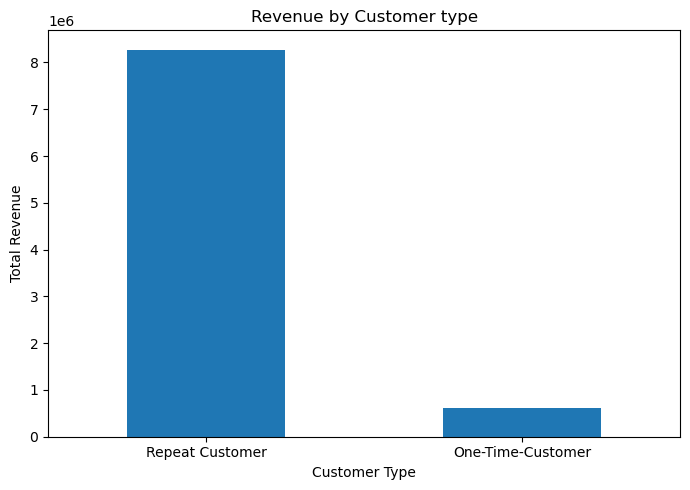

In [43]:
plt.figure(figsize=(7,5))

revenue_by_type.plot(kind='bar')

plt.title('Revenue by Customer type')
plt.xlabel('Customer Type')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** Repeat Customers accounts for 65.58% of the customer base but generate 93.09% of total revenue, while one-time customers contribute only 6.91%. This indicates that repeat purchasing behaviour is a major driver of overall revenue and highlights the importance of customer retention.

##### Monthly Active Customers

In [46]:
monthly_customers = (df_clean.groupby('PurchaseMonth')['CustomerID'].nunique().reset_index())

monthly_customers.columns = ['Month', 'ActiveCustomers']

monthly_customers

,Month,ActiveCustomers
0,2010-12-01,885
1,2011-01-01,741
2,2011-02-01,758
3,2011-03-01,974
4,2011-04-01,856
5,2011-05-01,1056
6,2011-06-01,991
7,2011-07-01,949
8,2011-08-01,935
9,2011-09-01,1266


**Note:** December 2011 represents a partial month because the dataset ends on 9 December 2011. Therefore, December figures should not be directly compared with complete months.

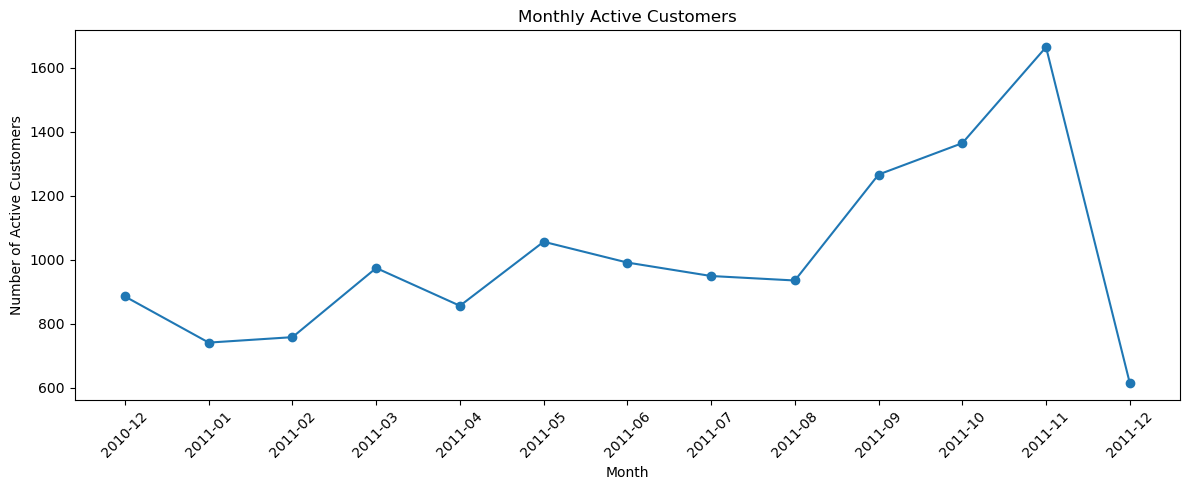

In [48]:
monthly_plot = monthly_customers.copy()
monthly_plot['Month'] = monthly_plot['Month'].dt.strftime('%Y-%m')

plt.figure(figsize=(12,5))

plt.plot(monthly_plot['Month'], monthly_plot['ActiveCustomers'], marker='o')

plt.title('Monthly Active Customers')
plt.xlabel('Month')
plt.ylabel('Number of Active Customers')
plt.xticks(rotation= 45)
plt.tight_layout()
plt.show()

##### Monthly Revenue Trend 

In [50]:
monthly_revenue = (df_clean.groupby('PurchaseMonth')['Revenue'].sum().reset_index())

monthly_revenue.columns = ['Month', 'Revenue']

monthly_revenue['Revenue'] = monthly_revenue['Revenue'].round(2)

monthly_revenue

,Month,Revenue
0,2010-12-01,570422.73
1,2011-01-01,568101.31
2,2011-02-01,446084.92
3,2011-03-01,594081.76
4,2011-04-01,468374.33
5,2011-05-01,677355.15
6,2011-06-01,660046.05
7,2011-07-01,598962.90
8,2011-08-01,644051.04
9,2011-09-01,950690.20


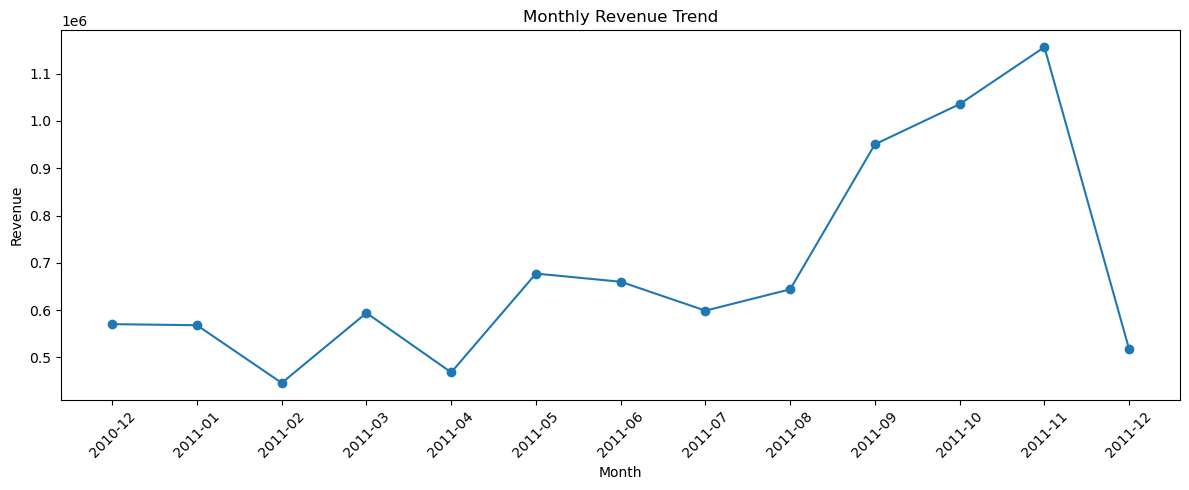

In [51]:
revenue_plot = monthly_revenue.copy()
revenue_plot['Month'] = revenue_plot['Month'].dt.strftime('%Y-%m')

plt.figure(figsize=(12,5))

plt.plot(revenue_plot['Month'], revenue_plot['Revenue'], marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation= 45)
plt.tight_layout()
plt.show()

##### Customer Revenue Analysis

In [53]:
# Top Customers by Revenue
customer_revenue = (df_clean.groupby('CustomerID')['Revenue'].sum().reset_index())

customer_revenue.columns = ['CustomerID', 'TotalRevenue']

customer_revenue = customer_revenue.sort_values('TotalRevenue', ascending= False)

customer_revenue['TotalRevenue'] = customer_revenue['TotalRevenue'].round(2)

customer_revenue.head(10)

,CustomerID,TotalRevenue
1689,14646,280206.02
4201,18102,259657.30
3728,17450,194390.79
3008,16446,168472.50
1879,14911,143711.17
55,12415,124914.53
1333,14156,117210.08
3771,17511,91062.38
2702,16029,80850.84
0,12346,77183.60


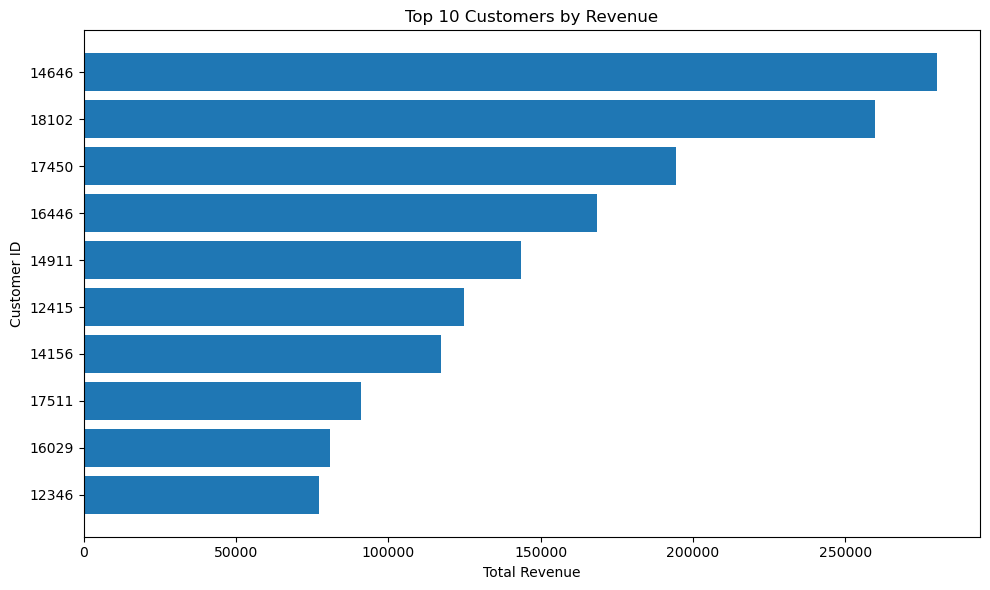

In [54]:
# Top 10 Customers by Revenue
top_customers = customer_revenue.head(10).copy()

top_customers['CustomerID'] = top_customers['CustomerID'].astype(str)

top_customers = top_customers.sort_values('TotalRevenue', ascending= True)

plt.figure(figsize=(10,6))

plt.barh(top_customers['CustomerID'], top_customers['TotalRevenue'])

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()

##### Purchase Frequency Analysis

In [56]:
# Customer Purchase Frequency
customer_orders['TotalOrders'].describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: TotalOrders, dtype: float64

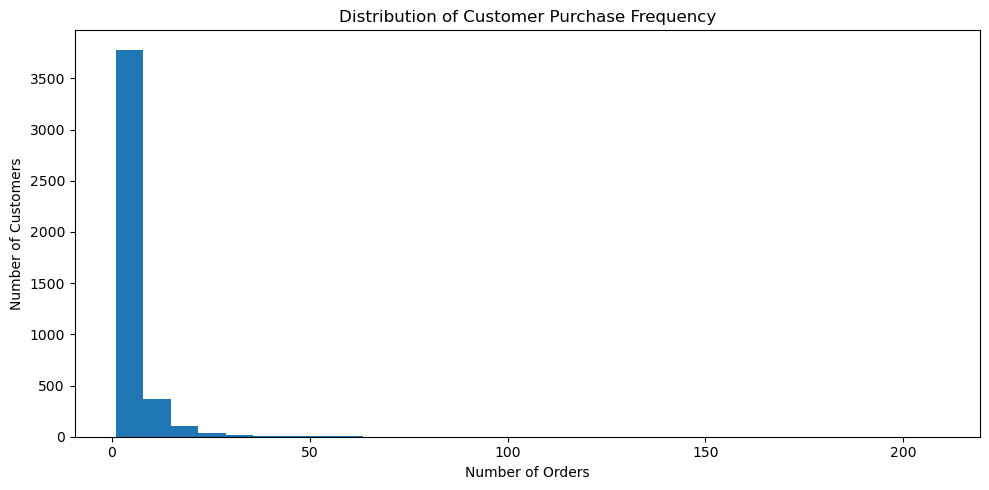

In [57]:
plt.figure(figsize=(10,5))

plt.hist(customer_orders['TotalOrders'],  bins=30)

plt.title('Distribution of Customer Purchase Frequency')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [58]:
customer_orders.sort_values('TotalOrders', ascending= False).head(10)

,CustomerID,TotalOrders,CustomerType
326,12748,209,Repeat Customer
1879,14911,201,Repeat Customer
4010,17841,124,Repeat Customer
562,13089,97,Repeat Customer
1661,14606,93,Repeat Customer
2176,15311,91,Repeat Customer
481,12971,86,Repeat Customer
1689,14646,73,Repeat Customer
2702,16029,63,Repeat Customer
795,13408,62,Repeat Customer


##### Country-Level Customer Analysis

In [60]:
# Customers by Country
country_customers = (df_clean.groupby('Country')['CustomerID'].nunique().sort_values(ascending= False).reset_index())

country_customers.columns = ['Country', 'UniqueCustomers']

country_customers.head(10)

,Country,UniqueCustomers
0,United Kingdom,3920
1,Germany,94
2,France,87
3,Spain,30
4,Belgium,25
5,Switzerland,21
6,Portugal,19
7,Italy,14
8,Finland,12
9,Austria,11


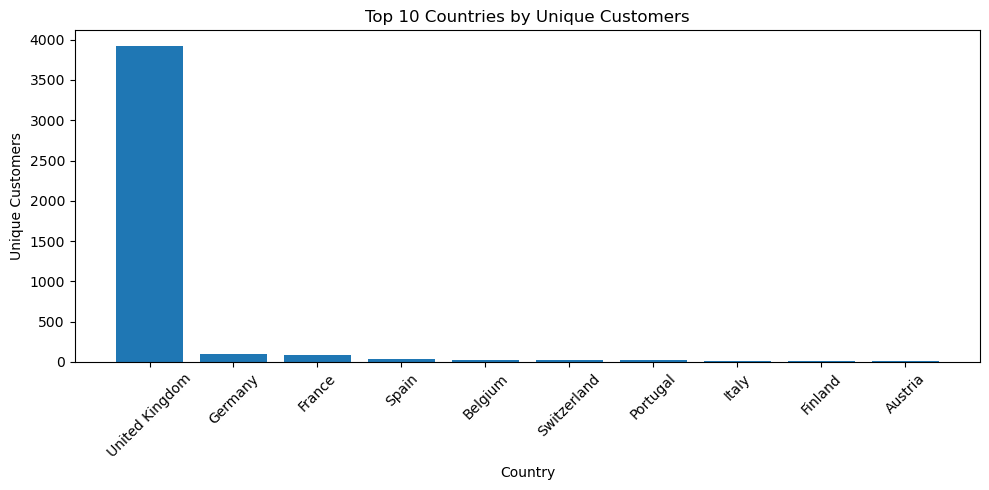

In [61]:
top_countries = country_customers.head(10)

plt.figure(figsize=(10,5))

plt.bar(top_countries['Country'], top_countries['UniqueCustomers'])

plt.title('Top 10 Countries by Unique Customers')
plt.xlabel('Country')
plt.ylabel('Unique Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Export Data for Power BI

In [63]:
# Create Final Dataset for Power BI
powerbi_data = df_clean.copy()

# Recreate Customer Type lookup for customer_orders
customer_lookup_df = customer_orders[['CustomerID', 'CustomerType']].drop_duplicates().copy()

# Verify it is a DataFrame
print(type(customer_lookup_df))
print(customer_lookup_df.head())

# Merge CustomerType into transaction-level data
powerbi_data = powerbi_data.merge(customer_lookup_df, on= 'CustomerID', how= 'left')

# Check Final Dataset
print("\nRows:", powerbi_data.shape[0])
print("Columns:", powerbi_data.shape[1])
print("\nMissing CustomerType:", powerbi_data['CustomerType'].isna().sum())

powerbi_data.head()

<class 'pandas.core.frame.DataFrame'>
   CustomerID       CustomerType
0       12346  One-Time-Customer
1       12347    Repeat Customer
2       12348    Repeat Customer
3       12349  One-Time-Customer
4       12350  One-Time-Customer

Rows: 392692
Columns: 13

Missing CustomerType: 0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,PurchaseMonth,CohortMonth,CohortIndex,CustomerType
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12-01,2010-12-01,1,Repeat Customer
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01,2010-12-01,1,Repeat Customer
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12-01,2010-12-01,1,Repeat Customer
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01,2010-12-01,1,Repeat Customer
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01,2010-12-01,1,Repeat Customer


In [64]:
powerbi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   InvoiceNo      392692 non-null  object        
 1   StockCode      392692 non-null  object        
 2   Description    392692 non-null  object        
 3   Quantity       392692 non-null  int64         
 4   InvoiceDate    392692 non-null  datetime64[ns]
 5   UnitPrice      392692 non-null  float64       
 6   CustomerID     392692 non-null  int32         
 7   Country        392692 non-null  object        
 8   Revenue        392692 non-null  float64       
 9   PurchaseMonth  392692 non-null  datetime64[ns]
 10  CohortMonth    392692 non-null  datetime64[ns]
 11  CohortIndex    392692 non-null  int32         
 12  CustomerType   392692 non-null  object        
dtypes: datetime64[ns](3), float64(2), int32(2), int64(1), object(5)
memory usage: 36.0+ MB


### Export Final Dataset

In [66]:
powerbi_data.to_csv('customer_retention_powerbi.csv', index= False)

print("Power BI Dataset Exported Successfully!")

Power BI Dataset Exported Successfully!


## 💡 Business Insights

- Repeat customers are the primary revenue driver.
- Customer retention declines after the first purchase period.
- Certain cohorts demonstrate stronger long-term retention.
- A small group of high-value customers contributes disproportionately to revenue.
- UK customers dominate the dataset's revenue contribution.

## 🎯 Business Recommendations

- Develop loyalty programs to encourage repeat purchases.
- Target first-time customers with second-purchase campaigns.
- Use personalized offers based on customer purchase history.
- Identify high-value customers for VIP and retention programs.
- Monitor cohort retention regularly to identify changes in customer behavior.

## ✅ Conclusion

This project analyzed customer purchasing behavior, revenue contribution,
and retention patterns using Python and cohort analysis.

The analysis identified repeat purchasing behavior, customer revenue
contribution, purchase frequency, geographic patterns, and retention
trends across customer cohorts.

The results show that repeat customers are a major driver of revenue,
highlighting the importance of customer retention and targeted customer
engagement strategies.

These insights can help businesses improve customer loyalty, increase
repeat purchases, and develop data-driven retention strategies.